In [ ]:
import sys, os
from pathlib import Path

project_root = Path("ddim-main").resolve()
sys.path.append(str(project_root))

print(project_root)

In [ ]:
import os
import logging
import time
import glob

import numpy as np
import pandas as pd
import math
import tqdm
import torch
import torch.utils.data as data
import os
from typing import Tuple, Union

import numpy as np
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T

In [ ]:


from models.diffusion import Model
from models.ema import EMAHelper
from functions import get_optimizer
from functions.p_losses import loss_registry
from skimage.metrics import structural_similarity as ssim
import torchvision.utils as tvu
import torchvision
from PIL import Image
import torch.nn.functional as F

import torchvision.utils as tvu
from torch.utils.tensorboard import SummaryWriter

## DATASET

In [7]:
import PAT
from PAT import PATDataset

In [ ]:
dataset = PATDataset(
    dataroot="./Vascular_Dataset/",  # your folder
    img_size=256,
    random_flip=True,
    split="train",
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

print("Number of images:", len(dataset))
for batch in dataloader:
    print("Batch image shape:", batch["image"].shape)
    break


Number of images: 9900
Batch image shape: torch.Size([8, 1, 256, 256])


## MODEL

In [ ]:
import diffusionpat
from diffusionpat import Diffusion
from omegaconf import OmegaConf

In [ ]:

# Load the YAML config file
config = OmegaConf.load("./configs/PAT.yml")

In [ ]:
class Args:
    def __init__(self, mode="train"):
        # -------------------------
        # COMMON SETTINGS
        # -------------------------
        self.dataset = "PAT"
        self.category = None
        self.seed = 42

        # -------------------------
        # PATHS
        # -------------------------
        self.log_path = "./logs_pat"          
        self.image_folder = "./samples_pat"   

        # -------------------------
        # TRAINING CONTROL
        # -------------------------
        self.resume_training = False          
        self.use_pretrained = False           

        # -------------------------
        # SAMPLING CONTROLS
        # -------------------------
        self.sample_type = "generalized"      
        self.skip_type = "uniform"            
        self.timesteps = 1000                   
        self.eta = 0.0                        
        self.skip = 1

        # These flags control what sample() does
        if mode == "train":
            self.fid = False
            self.sequence = False
        elif mode == "sample":
            self.fid = False      
            self.sequence = False 
        else:
            raise ValueError("mode must be 'train' or 'sample'")


In [14]:
args = Args(mode="train")
args.log_path = "./logs_pat_from_pretrained"
args.resume_training = True   

runner = Diffusion(args, config)
runner.train()

[TB] Logging to: ./runs_pat
[TRAIN] Found PAT checkpoint at ./logs_pat_from_pretrained/ckpt.pth, resuming...
[TRAIN] Resumed from epoch=70, step=86660
[TRAIN] Will train for 0 more epochs (0 steps remaining).
[TRAIN] Total training time: 0.00s | 0.00 min | 0.00 hours
[TRAIN] Final checkpoint saved. Training complete.


# INVERSE PROBLEM

## PATSYSTEM

In [ ]:
from tasks import  PAT_forward
import pat
import torch.nn.functional as F

In [17]:
def limited_view_rmd(N_transducer, N_keep):
  # the parity of N_transducer and N_keep must match
  edge = (N_transducer - N_keep) / 2
  return [i for i in range(N_transducer) if i < edge or i >= (N_transducer - edge)]

In [ ]:
R_ring         = 0.11
M              = 100 # image height in pixels
N              = 100 # image width in pixels
V_sound        = 1500 # speed of sound m/s
px             = 1e-3  # pixel size in meters
py             = 1e-3   # pixel size in meters

# Free parameters

N_transducer   = 100 
dt             = 0.5e-6 # sampling interval in seconds
center_freq    = 0.5e6
fwhm           = 0.5e6 

Diag = np.sqrt((py * (M / 2 - 0.5))**2 + (px * (N / 2 - 0.5))**2)  # half the major diagonal of the fov
T_min = (R_ring - Diag) / V_sound
T_max = (R_ring + Diag) / V_sound
T_max_n = round(T_max / dt)
T_min_n = round(T_min / dt)
T_min = T_min_n * dt

# number of samples per transducers, need N_sample * dt to cover the interval
# from T_min to T_max
N_sample = T_max_n - T_min_n + 1

# increasing oversampling makes more accurate forward matrix

oversample = 10
# padding for filtering, increase to make more accurate forward matrix
padsample = 50
Band = 1 / dt / 2

# Final config
PAT_config = [
    N_transducer, R_ring, px, py, M, N, dt,
    N_sample, oversample, padsample, T_min,
    center_freq, fwhm, V_sound
]

In [ ]:
import os
import torch

def load_or_generate_forward_model(
    A_path, y_path,
    GT, PAT_config,
    measurements_name='PAT_LV_test40.pt',
    A_name='A_LV40.pt',
    num_transducers=100,
    transducers_count=40
):
    # Ensure directories exist
    os.makedirs(os.path.dirname(y_path), exist_ok=True)
    os.makedirs(os.path.dirname(A_path), exist_ok=True)

    # If .pt files already exist, load them
    if os.path.exists(y_path) and os.path.exists(A_path):
        print("Loaded saved measurement and forward matrix.")
        y = torch.load(y_path)
        A = torch.load(A_path)
    else:
        print("Generating measurement and forward matrix from scratch...")

        # Generate mask of transducers to remove
        rmd = limited_view_rmd(num_transducers, transducers_count)

        # Simulate measurements and matrices
        y, P, L, T = PAT_forward(GT, PAT_config, add_noise=False, remove_transducers=True, removed_transducers=rmd)
        A = torch.matmul(torch.matmul(P, L), T)
        
        #y: Simulated photoacoustic measurements (i.e., the received pressure signals).

        #T: The basic transformation matrix from image domain to time samples (e.g., from flattened image to time signals).

        #L: Often used to model filtering operations (e.g., bandpass).

        #P: Model propagation effects ( preconditioning, noise shaping, or further system response).

        # Save them
        torch.save(y, y_path)
        torch.save(A, A_path)
        print(" Saved new measurement and forward matrix.")

    return A, y


In [ ]:
GT_test = torch.load("./GT/GT_test.pt")
print(GT_test.shape) 

torch.Size([100, 100, 100])


In [ ]:
A_file = "./Amatrix/A_LV40.pt"
y_file = "./measurements/PAT_LV_test40.pt"



In [ ]:
A, y = load_or_generate_forward_model(
    A_path=A_file,
    y_path=y_file,
    GT=GT_test,
    PAT_config=PAT_config,
    measurements_name='PAT_LV_test40.pt',
    A_name='A_LV40.pt',
    num_transducers=100,
    transducers_count=40
)


Loaded saved measurement and forward matrix.


In [ ]:
print(" A - Forward matrix:")
print("Type:", type(A))
print("Shape:", A.shape)

print("\ny - Measurement tensor:")
print("Type:", type(y))
print("Shape:", y.shape)


In [ ]:
import os
import torch

from models.diffusion import Model
from models.ema import EMAHelper


# 1. Paths 
checkpoint_dir  = "./logs_pat_from_pretrained"
checkpoint_file = os.path.join(checkpoint_dir, "ckpt.pth")   

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 2. Initialize model architecture
model = Model(config)              
model = model.to(device)
model = torch.nn.DataParallel(model)



# 3. Load checkpoint
states = torch.load(checkpoint_file, map_location=device)

# states: [state_dict, optimizer_state, epoch, step, (ema_state)]
model.load_state_dict(states[0], strict=True)

model.to(device)
model.eval()

print("Loaded checkpoint from:", checkpoint_file)
print(model)


Loaded checkpoint from: /home/700045831/ddim-main/ddim-main/logs_pat_from_pretrained/ckpt.pth
DataParallel(
  (module): Model(
    (temb): Module(
      (dense): ModuleList(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): Linear(in_features=256, out_features=256, bias=True)
      )
    )
    (conv_in): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down): ModuleList(
      (0): Module(
        (block): ModuleList(
          (0-1): 2 x ResnetBlock(
            (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (temb_proj): Linear(in_features=256, out_features=64, bias=True)
            (norm2): GroupNorm(32, 64, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
        )
        (attn): ModuleList()
        (downs

In [25]:
import diffusionpat
from diffusionpat import Diffusion
from diffusionpat import get_beta_schedule

In [ ]:
import torch

def ddim_reverse_step(
    x_t,
    t_idx,
    t_next,
    model,
    betas,
    alpha_bar,
    eta=0.0,
    clip_denoised=True,
):
    """
    One DDIM reverse step:
        x_t at timestep t_idx  ->  x_{t_next}  (typically t_next = t_idx-1)

    Args:
      x_t:        [B,C,H,W]
      t_idx:      int (current timestep)
      t_next:     int (next timestep; can be t_idx-1 or a larger jump, e.g. from a subsequence)
                 use -1 to mean "final" (alpha_bar = 1)
      model:      predicts eps = εθ(x_t, t)
      betas:      [T]
      alpha_bar:  [T] where alpha_bar[t] = prod_{s<=t} (1-beta_s)
      eta:        DDIM noise control (eta=0 -> deterministic DDIM, eta>0 -> stochastic)
      clip_denoised: clamp x0_hat to [-1,1]

    Returns:
      x_next:  sample at timestep t_next
      x0_hat:  predicted clean image at timestep t_idx
    """
    device = x_t.device
    B = x_t.size(0)

    
    ab_t = alpha_bar[t_idx]
    if t_next >= 0:
        ab_next = alpha_bar[t_next]
    else:
        ab_next = torch.ones_like(ab_t)  

    
    ab_t    = ab_t.view(1,1,1,1)
    ab_next = ab_next.view(1,1,1,1)

    
    t_tensor = torch.full((B,), float(t_idx), device=device)
    eps = model(x_t, t_tensor)

    
    x0_hat = (x_t - torch.sqrt(1.0 - ab_t) * eps) / torch.sqrt(ab_t)
    if clip_denoised:
        x0_hat = torch.clamp(x0_hat, -1.0, 1.0)

    
    if eta > 0.0:
        sigma = eta * torch.sqrt(
            (1.0 - ab_next) / (1.0 - ab_t) * (1.0 - ab_t / ab_next)
        )
    else:
        sigma = torch.zeros_like(ab_t)

    c1 = sigma
    c2 = torch.sqrt(torch.clamp(1.0 - ab_next - c1**2, min=0.0))

    
    if t_next >= 0:
        noise = torch.randn_like(x_t) if eta > 0.0 else 0.0
        x_next = torch.sqrt(ab_next) * x0_hat + c2 * eps + c1 * noise
    else:
        # final: return x0_hat
        x_next = x0_hat

    return x_next, x0_hat


## DDIM SAMPLING OF ONE IMAGE

In [ ]:
import torch
import torch.nn.functional as F
import tqdm as tq


device    = next(model.parameters()).device
low_sz    = 100     
high_sz   = 256     # UNet training size
etaa       = 1

#T = config.diffusion.num_diffusion_timesteps 
T = 50
beta_schedule = config.diffusion.beta_schedule
beta_start    = config.diffusion.beta_start
beta_end      = config.diffusion.beta_end

betas_np = get_beta_schedule(
    beta_schedule=beta_schedule,
    beta_start=beta_start,
    beta_end=beta_end,
    num_diffusion_timesteps=T,
)
betas     = torch.from_numpy(betas_np).float().to(device)   # [T]
alphas    = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)       


t_list = list(range(T-1, -1, -1)) 


o      = y[0:1].to(device)
o_flat = o.view(1, -1)
A      = A.to(device)
m, n   = A.shape
assert n == low_sz * low_sz

lam     = 0.999999995
I_n     = torch.eye(n, device=device)
ATA_inv = torch.inverse(lam * (A.T @ A) + (1.0 - lam) * I_n)


x_high = torch.randn(1, 1, high_sz, high_sz, device=device)
snapshots = []

model.eval()
with torch.no_grad():
    for t_idx in tq.tqdm(t_list, desc="(meas. consistency + denoising) steps"):
        
        t_next = t_idx - 1 if t_idx > 0 else -1
        
        
        x_0, x0_hat = ddim_reverse_step(
                x_t=x_high,
                t_idx=t_idx,
                t_next=t_next,
                model=model,
                betas=betas,
                alpha_bar=alpha_bar,
                eta=0.0,               # eta=0  deterministic DDIM
                clip_denoised=True,
        )
        
        snapshots.append(x0_hat.detach().cpu())
               
        x_low = F.interpolate(
            x0_hat,
            size=(low_sz, low_sz),
            mode="bilinear",
            align_corners=False,
        )  
        flat_x = x_low.view(1, -1)                          
        term_p = (1.0 - lam) * flat_x
        term_d = lam * (A.T @ o_flat.T).T                   
        flat_x = (ATA_inv @ (term_p + term_d).T).T          
        x_low  = flat_x.view_as(x_low)                      
        
        
        
        flat_x = x_low.view(1, -1)                  
        Ax     = flat_x @ A.T                      
        resid  = Ax - o_flat                        
        grad   = (A.T @ resid.T).view_as(x_low)     
        x_low  = (x_low - etaa * grad).clamp(0, 1)      
        x_high = F.interpolate(
            x_low,
            size=(high_sz, high_sz),
            mode="bilinear",
            align_corners=False,
        )

        
# final high-res reconstruction
x_recon_high = x0_hat.detach().cpu()   


(meas. consistency + denoising) steps: 100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 24.00it/s]


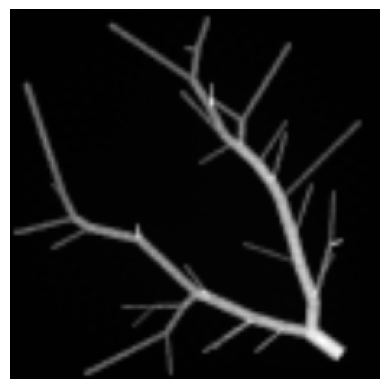

In [30]:

import matplotlib.pyplot as plt
imgr = x_recon_high.squeeze()
imgr = (imgr + 1) / 2   # map [-1,1] -> [0,1]
imgr = imgr.clamp(0,1).numpy()

plt.imshow(imgr, cmap='gray')
plt.axis('off')
plt.show()

## DDIM SAMPLING OF FEW IMAGES

Y_full shape: torch.Size([100, 1, 40, 188])




In [ ]:
import torch
import torch.nn.functional as F
import tqdm as tq
import matplotlib.pyplot as plt

device    = next(model.parameters()).device
low_sz    = 100
high_sz   = 256
etaa       = 1.0 

# ------------ SCHEDULE ------------
#T = config.diffusion.num_diffusion_timesteps
T = 50
beta_schedule = config.diffusion.beta_schedule
beta_start    = config.diffusion.beta_start
beta_end      = config.diffusion.beta_end

betas_np = get_beta_schedule(
    beta_schedule=beta_schedule,
    beta_start=beta_start,
    beta_end=beta_end,
    num_diffusion_timesteps=T,
)
betas     = torch.from_numpy(betas_np).float().to(device)
alphas    = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

t_list = list(range(T-1, -1, -1))    




Y_full = y.to(device)          
print("Y_full shape:", Y_full.shape) 

B = Y_full.shape[0]
num_samples =  B
#num_samples = min(5, B)
assert num_samples > 0, "No measurements available: Y_full batch size is 0."

A = A.to(device)
m, n = A.shape
assert n == low_sz * low_sz

lam     = 0.999999995
I_n     = torch.eye(n, device=device)
ATA_inv = torch.inverse(lam * (A.T @ A) + (1.0 - lam) * I_n)

final_recons = []

model.eval()
with torch.no_grad():
    for i in range(num_samples):
        # pick i-th measurement
        y_i    = Y_full[i:i+1]             
        y_flat = y_i.view(1, -1)           

        # init low-res latent
        x_high = torch.randn(1, 1, high_sz, high_sz, device=device)

        for t_idx in tq.tqdm(
            t_list,
            desc=f"(meas. consistency + denoising) sample {i}",
            leave=False,
        ):
            
            t_next = t_idx - 1 if t_idx > 0 else -1
            
            
            x_0, x0_hat = ddim_reverse_step(
                x_t=x_high,
                t_idx=t_idx,
                t_next=t_next,
                model=model,
                betas=betas,
                alpha_bar=alpha_bar,
                eta=0.0,               
                clip_denoised=True,
        )
            
            x_low = F.interpolate(
                x0_hat,
                size=(low_sz, low_sz),
                mode="bilinear",
                align_corners=False,
            )
            flat_x = x_low.view(1, -1)
            term_p = (1.0 - lam) * flat_x
            term_d = lam * (A.T @ y_flat.T).T
            flat_x = (ATA_inv @ (term_p + term_d).T).T
            x_low  = flat_x.view_as(x_low)
            
            
            
            flat_x = x_low.view(1, -1)                  
            Ax     = flat_x @ A.T                       
            resid  = Ax - y_flat                        
            grad   = (A.T @ resid.T).view_as(x_low)     
            x_low  = (x_low - etaa * grad).clamp(0, 1) 
            x_high = F.interpolate(
                x_low,
                size=(high_sz, high_sz),
                mode="bilinear",
                align_corners=False,
            )
            
        final_recons.append(x0_hat.detach().cpu())


fig, axes = plt.subplots(1, num_samples, figsize=(4*num_samples, 4))
if num_samples == 1:
    axes = [axes]

for i in range(num_samples):
    img = final_recons[i].squeeze()
    img = ((img + 1) / 2).clamp(0, 1).numpy()  

    ax = axes[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Sample {i} – last refined x₀")
    ax.axis("off")

plt.tight_layout()
plt.show()


## METRIC COMPUTATION

In [31]:
pip install torchmetrics lpips


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.8 MB/s eta 0:00:00
  Using cached typing_extensions-4.13.2-py3-none-any.whl (45 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-scheduler 2.10.0 requires fsspec<=2024.10.0,>=2023.6.0, but you have fsspec 2022.8.2 which is incompatible.
jupyter-scheduler 2.10.0 requires pytz<=2024.2,>=2023.3, but you have pytz 2022.4 which is incompatible.
jupyter-scheduler 2.10.0 requires sqlalchemy<3,>=2.0, but you have sqlalchemy 1.4.41 which is incompatible.
huggingface-hub 0.28.0 requires fsspec>=2023.5.0, but you have fsspec 2022.8.2 which is incompatible.
datasets 3.1.0 requires fsspec[http]<=2024.9.0,>=2023.1.0, but you have fsspec 2022.8.2 which is incompatible.
datasets 3.1.0 requires requests>=2.32.2, but you have reque

In [ ]:
import torch
import torch.nn.functional as F
import lpips


loss_fn_lpips = lpips.LPIPS(net='vgg').to(device)
loss_fn_lpips.eval()

lpips_vals = []

num_eval = len(final_recons)   

for i in range(num_eval):
    gt_t = GT_test[i].to(device)          
    if gt_t.ndim == 3:
        gt_t = gt_t.unsqueeze(0)          
    elif gt_t.ndim == 2:
        gt_t = gt_t.unsqueeze(0).unsqueeze(0)  

    
    recon_hr_t = final_recons[i].to(device)    
    recon_lr_t = F.interpolate(
        recon_hr_t,
        size=(gt_t.shape[-2], gt_t.shape[-1]),
        mode='bilinear',
        align_corners=False
    )                                          

    
    gt_min = gt_t.amin(dim=(-2, -1), keepdim=True)
    gt_max = gt_t.aman = gt_t.amax(dim=(-2, -1), keepdim=True)
    gt_norm = (gt_t - gt_min) / (gt_max - gt_min + 1e-12)

    recon_min = recon_lr_t.amin(dim=(-2, -1), keepdim=True)
    recon_max = recon_lr_t.amax(dim=(-2, -1), keepdim=True)
    recon_norm = (recon_lr_t - recon_min) / (recon_max - recon_min + 1e-12)

    
    gt_lp   = (gt_norm * 2.0 - 1.0).clamp(-1, 1)
    recon_lp = (recon_norm * 2.0 - 1.0).clamp(-1, 1)
    gt_lp_3   = gt_lp.repeat(1, 3, 1, 1)       
    recon_lp_3 = recon_lp.repeat(1, 3, 1, 1)   

    
    lpips_val = loss_fn_lpips(recon_lp_3, gt_lp_3).item()
    lpips_vals.append(lpips_val)

    print(f"Sample {i}: LPIPS = {lpips_val:.4f}")

print("\nAverage LPIPS over", num_eval, "samples:",
      f"{sum(lpips_vals)/len(lpips_vals):.4f}")


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/cm/shared/apps/anaconda3-2020.11/anaconda3-2020.11/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/cm/shared/apps/anaconda3-2020.11/anaconda3-2020.11/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/700045831/.local/lib/python3.8/site-packages/lpips/weights/v0.1/vgg.pth
Sample 0: LPIPS = 0.3080
Sample 1: LPIPS = 0.2863
Sample 2: LPIPS = 0.3024
Sample 3: LPIPS = 0.3413
Sample 4: LPIPS = 0.2719
Sample 5: LPIPS = 0.3020
Sample 6: LPIPS = 0.2972
Sample 7: LPIPS = 0.2896
Sample 8: LPIPS = 0.3733
Sample 9: LPIPS = 0.3129
Sample 10: LPIPS = 0.3399
Sample 11: LPIPS = 0.3352
Sample 12: LPIPS = 0.3466
Sample 13: LPIPS = 0.3561
Sample 14: LPIPS = 0.3443
Sample 15: LPIPS = 0.2816
Sample 16: LPIPS = 0.2822
Sample 17: LPIPS = 0.3223
Sample 18: LPIPS = 0.3093
Sample 19: LPIPS = 0.2940
Sample 20: LPIPS = 0.3605
Sample 21: LPIPS = 0.3094
Sample 22: LPIPS = 0.2940
Sample 23: LPIPS = 0.3066
Sample 24: LPIPS = 0.2755
Sample 25: LPIPS = 0.3316
Sample 26: LPIPS = 0.2969
Sample 27: LPIPS = 0.3357
Sample 28: LPIPS = 0.3085
Sample 29: LPIPS = 0.2767
Sample 30: LPIPS = 0.3375
Sample 31: LPIPS = 0.3126
Sample 32: LPIPS = 0.2751
Sample 33: LPIPS = 0.3235
Sample 34: LPIPS = 0.3280
Sa

In [ ]:
import torch.nn.functional as F
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

psnr_vals = []
ssim_vals = []

num_eval = len(final_recons)   # or use num_samples

for i in range(num_eval):

    gt_t = GT_test[i].to(device)          
    if gt_t.ndim == 3:
        gt_t = gt_t.unsqueeze(0)          
    elif gt_t.ndim == 2:
        gt_t = gt_t.unsqueeze(0).unsqueeze(0)  

    
    recon_hr_t = final_recons[i].to(device)       
    recon_lr_t = F.interpolate(
        recon_hr_t,
        size=(gt_t.shape[-2], gt_t.shape[-1]),
        mode='bilinear',
        align_corners=False
    )                                          

    
    gt_np    = gt_t.squeeze().cpu().numpy()       
    recon_np = recon_lr_t.squeeze().cpu().numpy()     
    gt_norm    = (gt_np - gt_np.min()) / (gt_np.max() - gt_np.min() + 1e-12)
    recon_norm = (recon_np - recon_np.min()) / (recon_np.max() - recon_np.min() + 1e-12)

    
    drange = gt_norm.max() - gt_norm.min()
    if drange == 0:   
        drange = 1.0

    psnr_val = peak_signal_noise_ratio(gt_norm, recon_norm, data_range=drange)
    ssim_val = structural_similarity(
        gt_norm,
        recon_norm,
        data_range=drange,
        win_size=11,
        channel_axis=None,   
    )

    psnr_vals.append(psnr_val)
    ssim_vals.append(ssim_val)

    print(f"Sample {i}: PSNR = {psnr_val:.2f} dB, SSIM = {ssim_val:.4f}")

# 6) Print averages over all evaluated samples
print("\nAverages over", num_eval, "samples:")
print(f"Mean PSNR = {sum(psnr_vals)/len(psnr_vals):.2f} dB")
print(f"Mean SSIM = {sum(ssim_vals)/len(ssim_vals):.4f}")


Sample 0: PSNR = 19.16 dB, SSIM = 0.4743
Sample 1: PSNR = 19.93 dB, SSIM = 0.5260
Sample 2: PSNR = 19.83 dB, SSIM = 0.3650
Sample 3: PSNR = 22.97 dB, SSIM = 0.3949
Sample 4: PSNR = 20.37 dB, SSIM = 0.4239
Sample 5: PSNR = 21.43 dB, SSIM = 0.4988
Sample 6: PSNR = 21.52 dB, SSIM = 0.5057
Sample 7: PSNR = 19.65 dB, SSIM = 0.4031
Sample 8: PSNR = 20.91 dB, SSIM = 0.3433
Sample 9: PSNR = 18.19 dB, SSIM = 0.3374
Sample 10: PSNR = 19.01 dB, SSIM = 0.3188
Sample 11: PSNR = 17.67 dB, SSIM = 0.3151
Sample 12: PSNR = 21.69 dB, SSIM = 0.3945
Sample 13: PSNR = 20.12 dB, SSIM = 0.4047
Sample 14: PSNR = 19.88 dB, SSIM = 0.4122
Sample 15: PSNR = 21.96 dB, SSIM = 0.4828
Sample 16: PSNR = 19.23 dB, SSIM = 0.4628
Sample 17: PSNR = 21.12 dB, SSIM = 0.4792
Sample 18: PSNR = 20.56 dB, SSIM = 0.4035
Sample 19: PSNR = 19.83 dB, SSIM = 0.4656
Sample 20: PSNR = 21.40 dB, SSIM = 0.3310
Sample 21: PSNR = 18.74 dB, SSIM = 0.3114
Sample 22: PSNR = 22.89 dB, SSIM = 0.4752
Sample 23: PSNR = 17.10 dB, SSIM = 0.3386
Sa